**Looping Graph**

Looping logiv to route the flow of data back to the nodes

Create a single conditional edge to handle decision-making and control graph flow.

**Goal:** Coding up Looping Logic

![Screenshot 2025-08-17 141722.png](<attachment:Screenshot 2025-08-17 141722.png>)
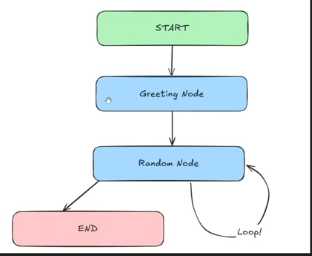

In [2]:
from langgraph.graph import StateGraph, END
import random
from typing import Dict, List, TypedDict

In [3]:
#state schema
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int



In [15]:
# build the nodes

def greeting_node(state: AgentState)->AgentState:
    """Greeting Node which say hi to the person"""
    state["name"]=f"Hi there, {state['name']}"
    state["counter"]=0

    return state

def random_node(state: AgentState)-> AgentState:
    """Genrates a random numbder from 0-10"""
    state["number"].append(random.randint(0,10))
    state['counter']+=1

    return state

def should_continue(state: AgentState)->AgentState:
    """Function to decide what to do next"""
    if state["counter"]<5:
        print("ENTERING LOOP", state["counter"])
        return "loop" #continue looping
    
    else:
        return "exit"     #Exit the loop

In [16]:
# make the graph
graph=StateGraph(AgentState)

#add the nodes
graph.add_node('greeting', greeting_node)
graph.add_node('random', random_node)

#connect the two nodes above
graph.add_edge('greeting', 'random')



#add the conditional edge now
graph.add_conditional_edges(
    "random", #source node
    should_continue, #Routing /Action
    {
        "loop":"random", #self-loop back to same node
        "exit":END    #end the graph
    }
)


graph.set_entry_point('greeting')

#compile the graph
app=graph.compile()

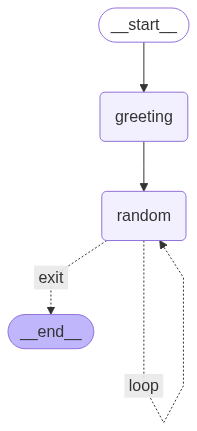

In [17]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [18]:
app.invoke({'name':'Allan', 'number':[], "counter":-1})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4


{'name': 'Hi there, Allan', 'number': [1, 6, 10, 10, 2], 'counter': 5}